# Notebook 01: Reproduce Toy DQI Demo

This notebook is a **canonical DQI reproduction notebook** on a tiny max-XORSAT instance. It is intentionally separate from the BMW pricing-model contribution notebooks.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

try:
    from notebooks._helpers import repo_root
except ModuleNotFoundError:
    from _helpers import repo_root

ROOT = repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.dqi_state import run_dqi_statevector
from src.reduction import surrogate_objective_unweighted, count_satisfied
from notebooks._helpers import plot_distribution, distribution_table_with_scores

SEED = 7
np.random.seed(SEED)

print('numpy:', np.__version__)
print('pennylane:', qml.__version__)

numpy: 2.2.6
pennylane: 0.43.1


## Define a tiny canonical max-XORSAT instance

In [2]:
B = np.array([
    [1, 0, 1, 0],
    [0, 1, 1, 0],
    [1, 1, 0, 1],
    [0, 0, 1, 1],
    [1, 0, 0, 1],
    [0, 1, 0, 1],
], dtype=np.int8)
v = np.array([0, 1, 0, 1, 0, 1], dtype=np.int8)

m, n_bits = B.shape
print(f'n_bits={n_bits}, m={m}')

n_bits=4, m=6


## Exact classical reference

In [3]:
rows = []
for x in range(2 ** n_bits):
    rows.append({
        'x': x,
        'bitstring': format(x, f'0{n_bits}b'),
        'satisfied_clauses': count_satisfied(x, B, v, n_bits),
        'G_unweighted': surrogate_objective_unweighted(x, B, v, n_bits),
    })
exact_df = pd.DataFrame(rows).sort_values(['satisfied_clauses', 'G_unweighted'], ascending=False)
x_star = int(exact_df.iloc[0]['x'])
max_sat = int(exact_df.iloc[0]['satisfied_clauses'])
exact_df.head(8)

,x,bitstring,satisfied_clauses,G_unweighted
11,11,1011,5,4
2,2,0010,4,2
4,4,0100,4,2
5,5,0101,4,2
9,9,1001,4,2
14,14,1110,4,2
0,0,0000,3,0
1,1,0001,3,0


## Run DQI end-to-end (baseline $\ell=2$)

In [4]:
ell = 2
alpha = np.ones(ell + 1, dtype=np.float64)
alpha /= np.linalg.norm(alpha)

samples, probs, success_prob = run_dqi_statevector(B=B, v=v, alpha=alpha, ell=ell, n_samples=4000, seed=SEED)
print(f'Decoding/postselection success probability: {success_prob:.4f}')
print(f'Unique sampled states: {len(np.unique(samples))}/{2**n_bits}')

Decoding/postselection success probability: 0.5000
Unique sampled states: 16/16


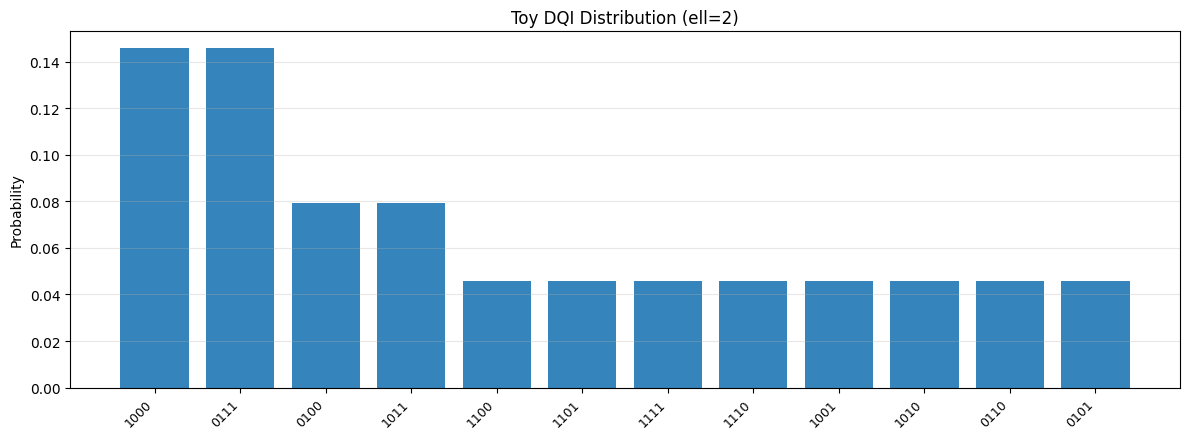

Saved figure: /Users/zenith/Desktop/dqi-pricing-benchmark/figures/notebook01_toy_histogram.png


In [5]:
fig, ax = plot_distribution(probs, top_k=12, title='Toy DQI Distribution (ell=2)')
out_path = ROOT / 'figures' / 'notebook01_toy_histogram.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=160, bbox_inches='tight')
plt.show()
print('Saved figure:', out_path)

In [6]:
topk = distribution_table_with_scores(
    probabilities=probs,
    top_k=12,
    score_fn=lambda x: float(count_satisfied(x, B, v, n_bits)),
    score_label='satisfied_clauses',
    optimum_x=x_star,
)
topk

,bitstring,probability,satisfied_clauses,optimal
0,1000,0.145833,0.0,False
1,0111,0.145833,1.0,False
2,0100,0.079167,4.0,False
3,1011,0.079167,5.0,True
4,1100,0.045833,3.0,False
5,1101,0.045833,3.0,False
6,1111,0.045833,2.0,False
7,1110,0.045833,4.0,False
8,1001,0.045833,4.0,False
9,1010,0.045833,3.0,False


## Five-stage map (what each DQI step does)
1. **Dicke superposition:** prepares low-weight error patterns.
2. **Phase kick:** encodes clause target parities $v$ into phase signs.
3. **Syndrome compute:** maps error pattern to syndrome $B^T y$.
4. **Decode/uncompute:** keeps decodable branches and removes error register.
5. **Hadamard + measure:** interferes amplitudes, then samples candidate bitstrings.

## Knob study: change $\ell$

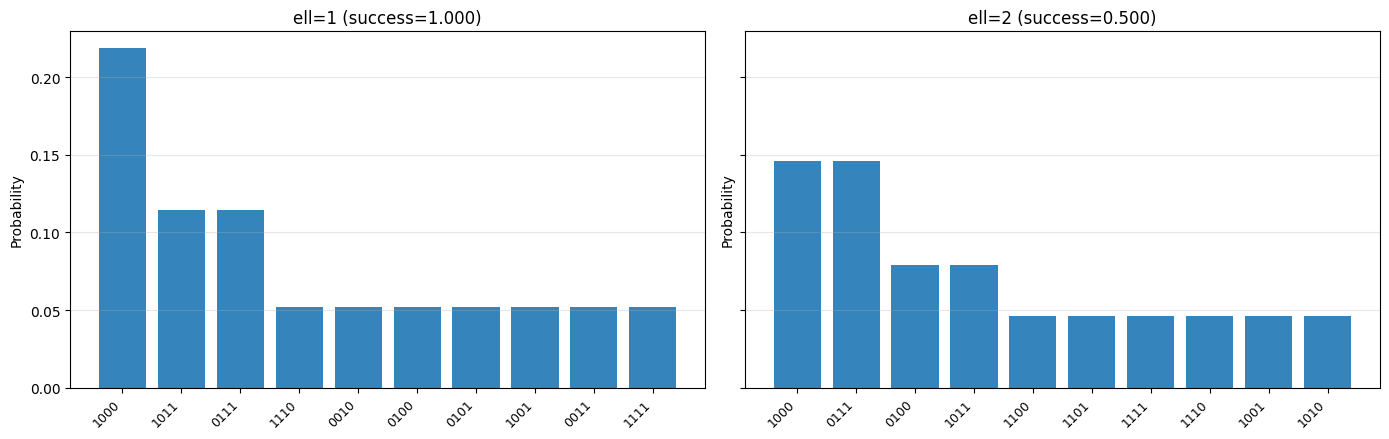

In [7]:
def run_for_ell(ell_value: int):
    a = np.ones(ell_value + 1, dtype=np.float64)
    a /= np.linalg.norm(a)
    _, p, s = run_dqi_statevector(B=B, v=v, alpha=a, ell=ell_value, n_samples=4000, seed=SEED)
    return p, s

probs_ell1, success_ell1 = run_for_ell(1)
probs_ell2, success_ell2 = run_for_ell(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
plot_distribution(probs_ell1, top_k=10, title=f'ell=1 (success={success_ell1:.3f})', ax=axes[0])
plot_distribution(probs_ell2, top_k=10, title=f'ell=2 (success={success_ell2:.3f})', ax=axes[1])
plt.tight_layout()
plt.show()

**Interpretation:** Increasing $\ell$ changes the supported error-weight sectors and therefore the final interference pattern. Even on this tiny instance, the output distribution shifts visibly across candidate bitstrings.